Name: Mingze Geng

Github Username: Mingze88

USC ID: 1418612987

### (a) Download and Load the Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

df = pd.read_excel("Folds5x2_pp.xlsx", sheet_name="Sheet1")

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b)

#### (i)

In [8]:
print(df.shape)
print(df.columns)

(9568, 5)
Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')


There are 9,568 rows and 5 columns. Each row is one hourly observation from the power plant. The four predictor columns are `AT`, `V`, `AP`, and `RH`, and the response column is `PE`.

#### (ii)

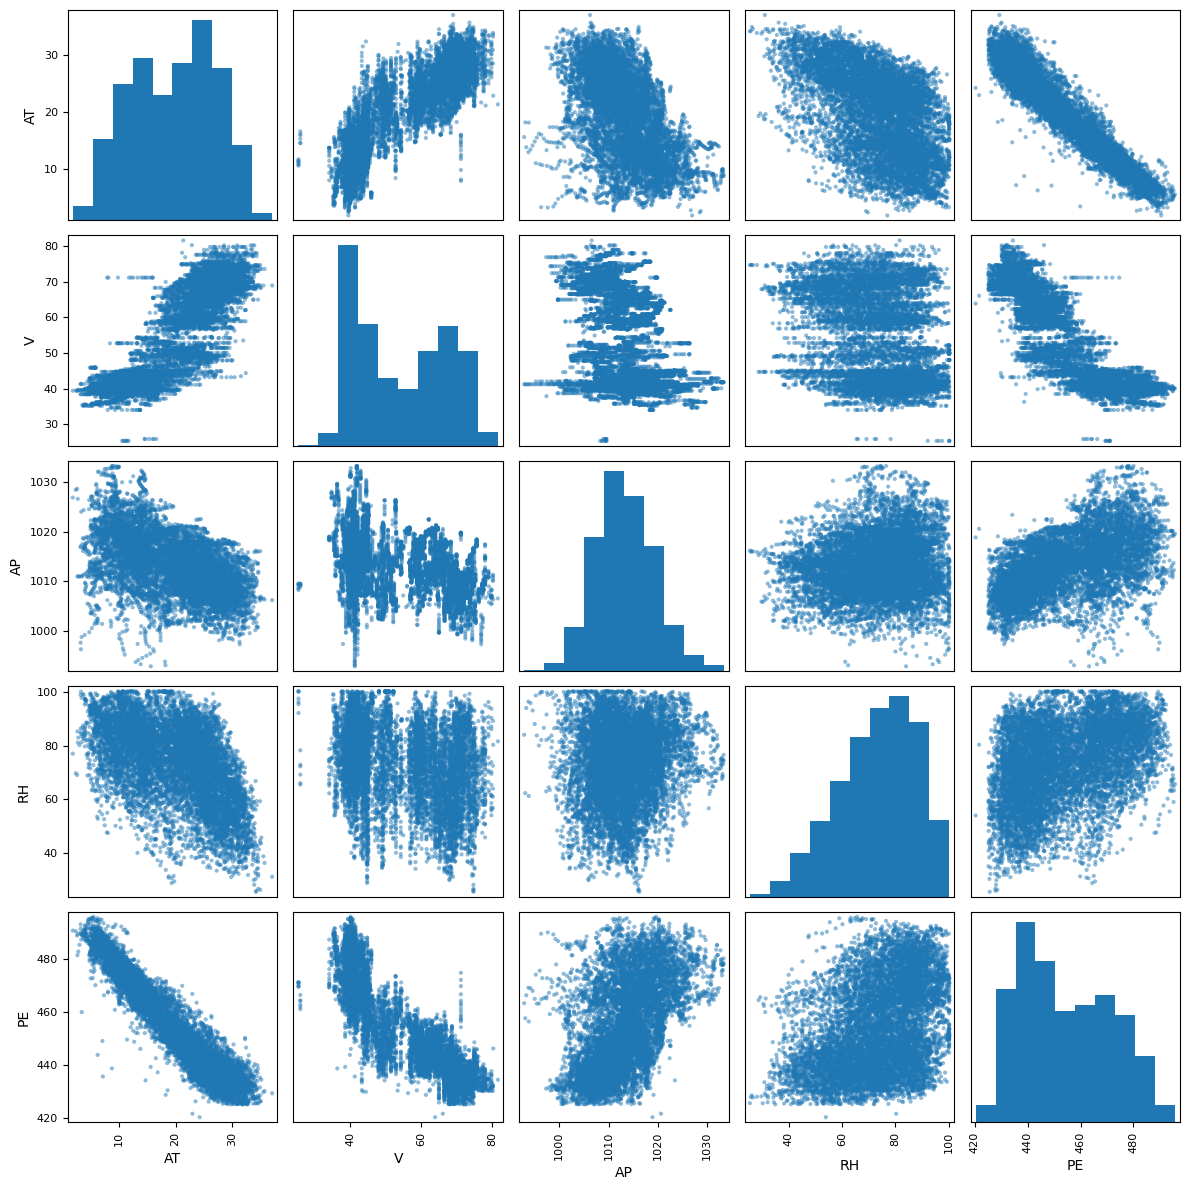

In [11]:
pd.plotting.scatter_matrix(df, figsize=(12, 12), diagonal="hist")
plt.tight_layout()
plt.show()

In [12]:
print(df.corr())

          AT         V        AP        RH        PE
AT  1.000000  0.844107 -0.507549 -0.542535 -0.948128
V   0.844107  1.000000 -0.413502 -0.312187 -0.869780
AP -0.507549 -0.413502  1.000000  0.099574  0.518429
RH -0.542535 -0.312187  0.099574  1.000000  0.389794
PE -0.948128 -0.869780  0.518429  0.389794  1.000000


`AT` has the strongest relationship with `PE`, and the relationship is strongly negative. As temperature increases, electrical power output usually decreases. `V` also has a strong negative relationship with `PE`. `AP` has a moderate positive relationship with `PE`, while `RH` has a weaker positive relationship.

Some predictors are also highly correlated with each other. In particular, `AT` and `V` have a correlation of about 0.844. This strong correlation is important when we compare the coefficients from simple regression and multiple regression.

#### (iii) 

In [15]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c)

In [17]:
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}

for x in predictors:
    model = smf.ols(f"PE ~ {x}", data=df).fit()
    simple_models[x] = model

    print("\n", x)
    print(model.summary())


 AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:22:48   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280    

Therefore, all four predictors have statistically significant marginal associations with PE.
AT gives the strongest simple linear regression, explaining approximately 89.9% of the variability in PE.

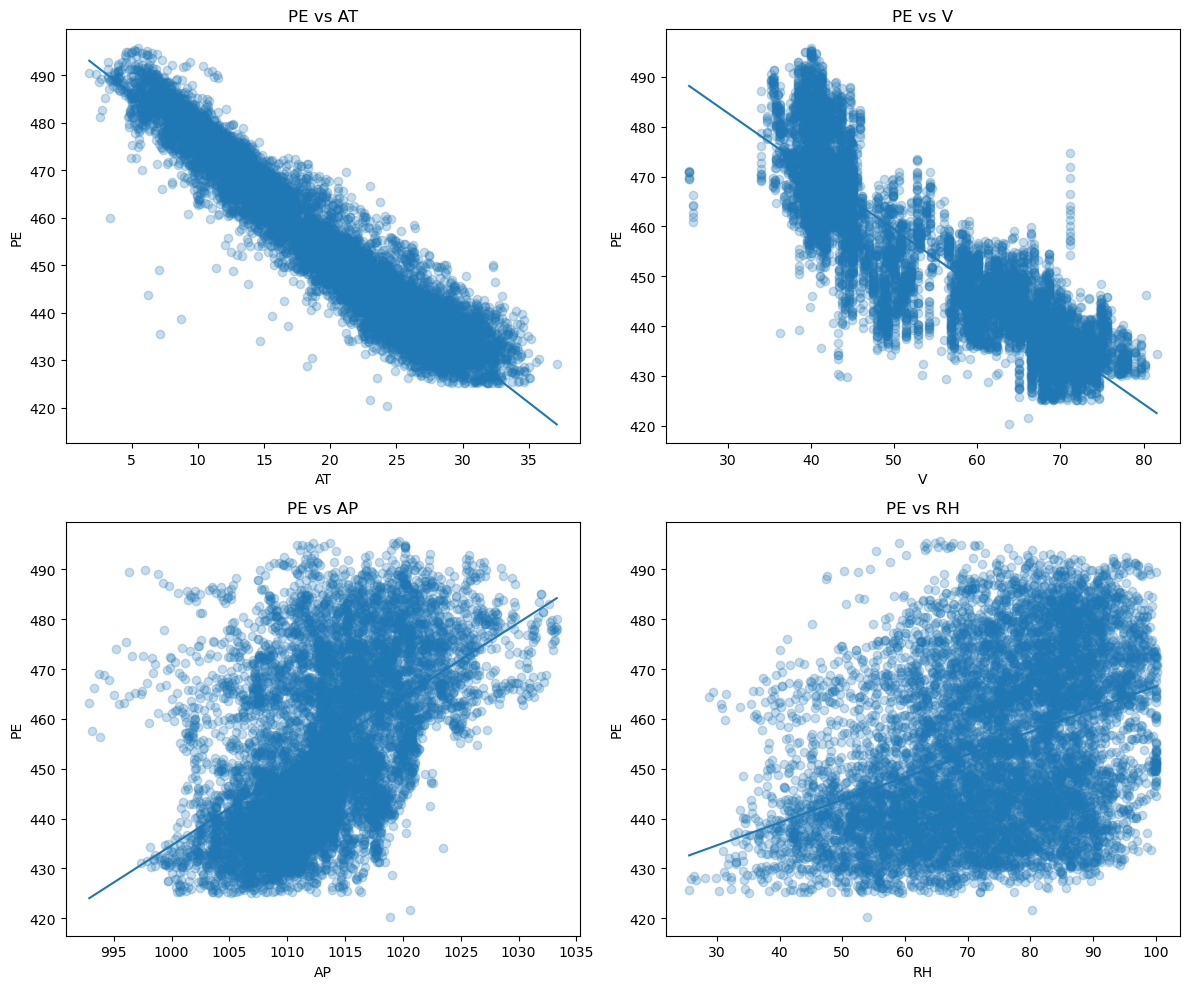

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, x in zip(axes.flatten(), predictors):
    ax.scatter(df[x], df["PE"], alpha=0.25)

    model = simple_models[x]
    x_grid = np.linspace(df[x].min(), df[x].max(), 200)

    y_grid = model.params["Intercept"] + model.params[x] * x_grid

    ax.plot(x_grid, y_grid)
    ax.set_xlabel(x)
    ax.set_ylabel("PE")
    ax.set_title(f"PE vs {x}")

plt.tight_layout()
plt.show()

Some observations have relatively large residuals. However, large residuals alone are not a good reason to remove them. The observations still look reasonable for the plant data. They do not look like clear data-entry errors. I would keep these observations unless more information shows that they are incorrect.

### (d)

In [22]:
multiple_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=df
).fit()

print(multiple_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:22:49   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

The fitted model is approximately

$$
\widehat{PE} = 454.609 - 1.978(AT) - 0.234(V) + 0.062(AP) - 0.158(RH).
$$

The model has

$$ R^2 \approx 0.929. $$

Thus, the four predictors together explain approximately 92.9% of the variability in PE.

At the 5% significance level, we reject

$$ H_0:\beta_j=0 $$

for AT, V, AP, and RH.

### (e)

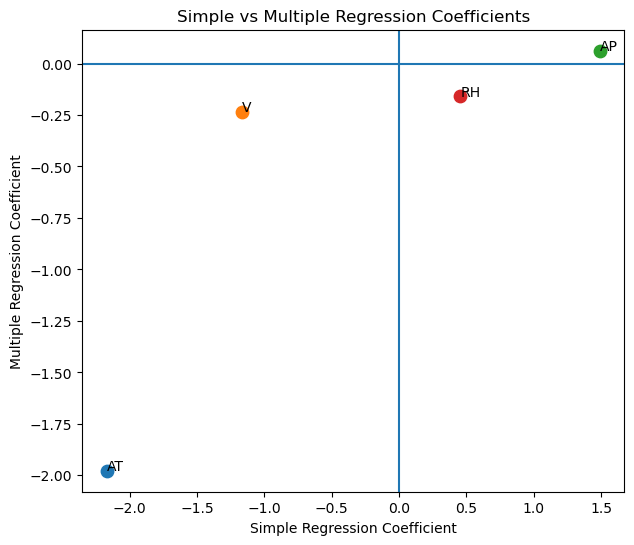

In [25]:
simple_coef = []
multiple_coef = []

for x in predictors:
    simple_coef.append(simple_models[x].params[x])
    multiple_coef.append(multiple_model.params[x])

plt.figure(figsize=(7, 6))

for i, x in enumerate(predictors):
    plt.scatter(simple_coef[i], multiple_coef[i], s=80)
    plt.annotate(x, (simple_coef[i], multiple_coef[i]))

plt.axhline(0)
plt.axvline(0)
plt.xlabel("Simple Regression Coefficient")

plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple vs Multiple Regression Coefficients")
plt.show()


The coefficients can change substantially after adjustment for the other predictors. The clearest example is `RH`: its simple-regression coefficient is positive, but its multiple-regression coefficient is negative. This happens because the predictors are correlated. A simple regression measures a marginal association, whereas multiple regression measures the association with `PE` after controlling for the other predictors.

### (f)

In [28]:
for x in predictors:

    model = smf.ols(
        f"PE ~ {x} + I({x}**2) + I({x}**3)",
        data=df
    ).fit()

    print("\n", x)
    print(model.summary())


 AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:22:49   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248    

For each predictor, the fitted model is

$$
PE = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon.
$$

There is evidence of a nonlinear relationship for all four predictors when the quadratic and cubic terms are tested together. For `AT`, `AP`, and `RH`, the higher-order terms are clearly significant. For `V`, the quadratic term is not significant by itself, but the cubic term is significant. The joint test for the nonlinear terms is also highly significant.

### (g)

In [31]:
interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH)**2",
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:22:49   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

At $\alpha = 0.05$, the statistically significant interaction terms are:
$$ AT\times V,\quad AT\times RH,\quad V\times AP,\quad AP\times RH. $$

Thus, there is evidence that the effect of one predictor on PE can depend on the value of another predictor.


### (h) 

In [34]:
train, test = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

model_linear = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train
).fit()

train_pred = model_linear.predict(train)
test_pred = model_linear.predict(test)

linear_train_mse = mean_squared_error(train["PE"], train_pred)
linear_test_mse = mean_squared_error(test["PE"], test_pred)

print(linear_train_mse, linear_test_mse)

20.58083972573871 21.239856938225284


In [35]:
full_model = smf.ols(
    """PE ~ AT + V + AP + RH
       + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)
       + AT:V + AT:AP + AT:RH
       + V:AP + V:RH + AP:RH""",
    data=train
).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:22:49   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

Based on the p-values from the full model, I remove the insignificant
quadratic and interaction terms while retaining the corresponding main
effects. The reduced model is fitted below.

In [37]:
improved_model = smf.ols(
    """PE ~ AT + V + AP + RH
       + I(AT**2) + I(AP**2) + I(RH**2)
       + AT:V + AT:RH + AP:RH""",
    data=train
).fit()

print(improved_model.summary())

train_pred = improved_model.predict(train)
test_pred = improved_model.predict(test)

improved_train_mse = mean_squared_error(
    train["PE"], train_pred
)

improved_test_mse = mean_squared_error(
    test["PE"], test_pred
)

print(improved_train_mse, improved_test_mse)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:22:49   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.046e+04   1091.512     -9.581      0.0

Therefore, adding selected nonlinear and interaction terms improves predictive performance. The test MSE decreases from approximately 21.24 to 18.69.


### (i)

In [40]:
X_train = train[predictors]
X_test = test[predictors]

y_train = train["PE"]
y_test = test["PE"]

ks = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in ks:

    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    raw_train_mse.append(
        mean_squared_error(
            y_train,
            knn.predict(X_train)
        )
    )

    raw_test_mse.append(
        mean_squared_error(
            y_test,
            knn.predict(X_test)
        )
    )

best_raw_k = np.argmin(raw_test_mse) + 1

print(best_raw_k)
print(min(raw_test_mse))

5
15.726819842563568


In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

norm_train_mse = []
norm_test_mse = []

for k in ks:

    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(
        X_train_scaled,
        y_train
    )

    norm_train_mse.append(
        mean_squared_error(
            y_train,
            knn.predict(X_train_scaled)
        )
    )

    norm_test_mse.append(
        mean_squared_error(
            y_test,
            knn.predict(X_test_scaled)
        )
    )

best_norm_k = np.argmin(norm_test_mse) + 1

print(best_norm_k)
print(min(norm_test_mse))

4
14.305669422675024


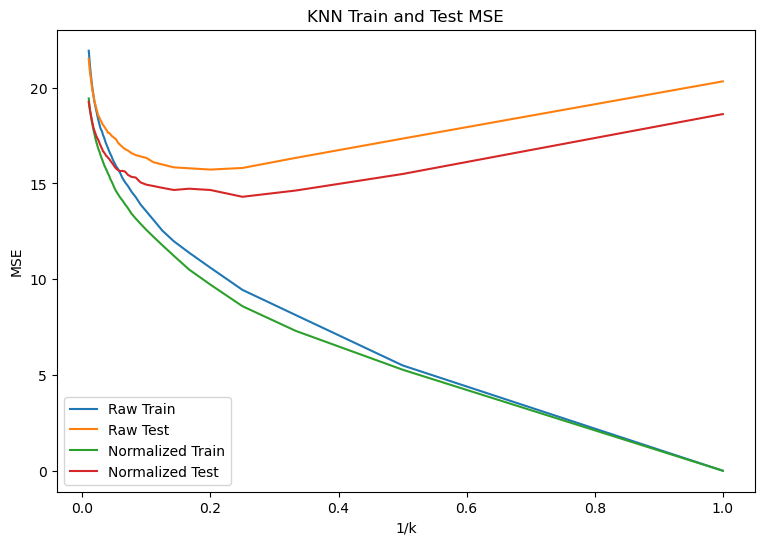

In [42]:
inverse_k = 1 / np.array(list(ks))

plt.figure(figsize=(9, 6))

plt.plot(
    inverse_k,
    raw_train_mse,
    label="Raw Train"
)

plt.plot(
    inverse_k,
    raw_test_mse,
    label="Raw Test"
)

plt.plot(
    inverse_k,
    norm_train_mse,
    label="Normalized Train"
)

plt.plot(
    inverse_k,
    norm_test_mse,
    label="Normalized Test"
)

plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Train and Test MSE")
plt.legend()
plt.show()

### (j)

The normalized KNN model has the lowest test MSE among the models. Its test MSE is about 14.31. The improved regression model has a higher test MSE of about 18.69.

These results show that the relationship between the environmental variables and power output is not fully linear. The polynomial and interaction regression model performs better than the basic multiple linear regression model. KNN performs even better because it can capture nonlinear patterns in the data without assuming a fixed equation.

Normalization also improves the KNN model. KNN uses distances between data points. If the features have different scales, features with larger values can have more influence on the distance calculation. Normalization puts the features on a similar scale and helps KNN make better predictions.


### 2.4.1

#### (a)

A flexible method would usually perform better. The sample size is very large, and the number of predictors is small. The large amount of data helps the model learn complex patterns. It also lowers the risk of overfitting.

#### (b)

A flexible method would usually perform worse. The number of predictors is very large, but the sample size is small. A flexible model can fit the training data too closely. This can lead to overfitting and poor performance on new data.

#### (c)

A flexible method would usually perform better. The relationship between the predictors and the response is highly nonlinear. A flexible model can capture this type of pattern better. An inflexible model may be too simple.

#### (d)

A flexible method would usually perform worse. The error variance is very high. This means the data contain a lot of noise. A flexible model may fit the noise instead of the true pattern. An inflexible model is less likely to do this.

## 2.4.7

### (a)

The Euclidean distance between an observation and the test point $(0,0,0)$ is

$$
d = \sqrt{(X_1-0)^2 + (X_2-0)^2 + (X_3-0)^2}.
$$

For each observation,

$$
d_1 = \sqrt{0^2 + 3^2 + 0^2} = 3
$$

$$
d_2 = \sqrt{2^2 + 0^2 + 0^2} = 2
$$

$$
d_3 = \sqrt{0^2 + 1^2 + 3^2}
= \sqrt{10}
\approx 3.162
$$

$$
d_4 = \sqrt{0^2 + 1^2 + 2^2}
= \sqrt{5}
\approx 2.236
$$

$$
d_5 = \sqrt{(-1)^2 + 0^2 + 1^2}
= \sqrt{2}
\approx 1.414
$$

$$
d_6 = \sqrt{1^2 + 1^2 + 1^2}
= \sqrt{3}
\approx 1.732
$$

### (b)

For $K=1$, the nearest observation is Observation 5.

Its distance is

$$
d_5 = \sqrt{2} \approx 1.414.
$$

Observation 5 has class Green.

Therefore,

$$
{\text{Prediction = Green}}
$$

### (c)

For $K=3$, the three nearest observations are

$$
\text{Observation 5: Green}
$$

$$
\text{Observation 6: Red}
$$

$$
\text{Observation 2: Red}
$$

There are two Red observations and one Green observation.

Therefore,

$$
{\text{Prediction = Red}}
$$

### (d)

If the Bayes decision boundary is highly nonlinear, a small value of $K$ is usually better.

A small $K$ makes KNN more flexible. It can follow a complex decision boundary more closely.

A large $K$ creates a smoother decision boundary. It may miss nonlinear patterns.

Therefore,

$$
{\text{A small value of } K}
$$

